In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, f1_score)
from sklearn.inspection import permutation_importance

# Estadística
import scipy.stats as stats
import pingouin as pg

# Configuración
%matplotlib inline
sns.set(font_scale=1.2, style='ticks')
plt.rcParams['figure.dpi'] = 100

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


In [2]:
# Cargamos el CSV generado al final del análisis conductual
data_path = 'CJ_EEG_clean.csv'   # ajusta la ruta si es necesario
df = pd.read_csv(data_path)

print(f'Dataset cargado: {df.shape[0]} filas, {df.shape[1]} columnas')
print(f'\nColumnas disponibles:\n{list(df.columns)}')
df.head(3)

Dataset cargado: 6537 filas, 40 columnas

Columnas disponibles:
['exp_ID', 'npar', 'subj', 'nblock', 'ntrial', 'nrep', 'cond-1', 'trial_type', 'rDV', 'deci-3', 'deci-2', 'deci-1', 'cond', 'deci', 'DV', 'resp', 'corr-1', 'r_map', 'correct', 'confi', 'RT', 'd1', 'd2', 'd3', 'd4', 'd5', 'd6', 'o1', 'o2', 'o3', 'o4', 'o5', 'o6', 'metad', 'metad_3%', 'metad_97%', 'switch', 'conf_lvl', 'confi-1', 'correct-1']


,exp_ID,npar,subj,nblock,ntrial,nrep,cond-1,trial_type,rDV,deci-3,...,o4,o5,o6,metad,metad_3%,metad_97%,switch,conf_lvl,confi-1,correct-1
0,CJ_EEG,1,s01,0,0,0,0,repeat,-0.203974,0,...,1.576,1.214,1.549,0.086,-0.345,0.51,0,L,NaN,0
1,CJ_EEG,1,s01,0,0,1,0,repeat,-0.203974,0,...,1.576,1.214,1.549,0.086,-0.345,0.51,0,H,-0.1,1
2,CJ_EEG,1,s01,0,0,2,0,repeat,-0.203974,0,...,1.576,1.214,1.549,0.086,-0.345,0.51,0,H,0.6,1


In [3]:
# ── VARIABLE OBJETIVO ────────────────────────────────────────────────────────
# Predecimos deci: 0 = cardinal, 1 = diagonal
target = 'deci'

# ── FEATURES CONDUCTUALES ────────────────────────────────────────────────────
# Evidencia sensorial
sensory_features = ['rDV', 'd1', 'd2', 'd3', 'd4', 'd5', 'd6']

# Historia de decisiones (confirmation bias)
history_features = ['deci-1', 'deci-2', 'deci-3', 'corr-1', 'cond-1']

# Comportamiento del participante
behav_features = ['RT', 'confi', 'nrep']

# Variables de diseño experimental
design_features = ['trial_type']  # la convertiremos a numérica

# Metacognición (nivel participante)
meta_features = ['metad']

# Todas juntas
all_features = sensory_features + history_features + behav_features + meta_features

print('Features seleccionadas:')
print(f'  Sensoriales   : {sensory_features}')
print(f'  Historia       : {history_features}')
print(f'  Conductuales   : {behav_features}')
print(f'  Metacognición  : {meta_features}')
print(f'  TOTAL          : {len(all_features)} features')

Features seleccionadas:
  Sensoriales   : ['rDV', 'd1', 'd2', 'd3', 'd4', 'd5', 'd6']
  Historia       : ['deci-1', 'deci-2', 'deci-3', 'corr-1', 'cond-1']
  Conductuales   : ['RT', 'confi', 'nrep']
  Metacognición  : ['metad']
  TOTAL          : 16 features


In [4]:
df_ml = df.copy()

# Convertir trial_type a numérica: repeat=1, nonrepeat=0
df_ml['trial_type_num'] = (df_ml['trial_type'] == 'repeat').astype(int)
all_features_num = all_features + ['trial_type_num']

# Eliminar filas con NaN en las features o en el target
df_ml = df_ml[all_features_num + [target]].dropna()

print(f'Filas tras eliminar NaN: {len(df_ml)}')
print(f'Distribución del target:')
print(df_ml[target].value_counts(normalize=True).round(3))

# Separar X e y
X = df_ml[all_features_num].values
y = df_ml[target].values

print(f'\nShape X: {X.shape}')
print(f'Shape y: {y.shape}')

Filas tras eliminar NaN: 6274
Distribución del target:
deci
1    0.559
0    0.441
Name: proportion, dtype: float64

Shape X: (6274, 17)
Shape y: (6274,)


Cardinal  (0): 2766 (44.1%)
Diagonal  (1): 3508 (55.9%)
Ratio     : 1.27

Atención: clases desbalanceadas → considerar class_weight="balanced".


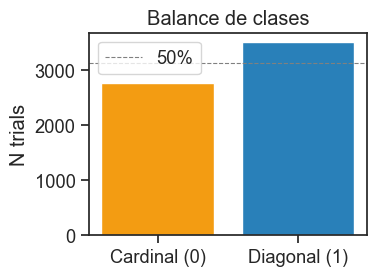

In [5]:
# Es importante verificar que las clases están balanceadas
# Si no lo están, los modelos tenderán a predecir siempre la clase mayoritaria
n_cardinal = (y == 0).sum()
n_diagonal = (y == 1).sum()
total = len(y)

print(f'Cardinal  (0): {n_cardinal} ({n_cardinal/total*100:.1f}%)')
print(f'Diagonal  (1): {n_diagonal} ({n_diagonal/total*100:.1f}%)')
print(f'Ratio     : {n_diagonal/n_cardinal:.2f}')

if abs(n_cardinal - n_diagonal) / total < 0.1:
    print('\nClases suficientemente balanceadas → no se requiere resampling.')
else:
    print('\nAtención: clases desbalanceadas → considerar class_weight="balanced".')

# Visualización
fig, ax = plt.subplots(figsize=(4, 3))
ax.bar(['Cardinal (0)', 'Diagonal (1)'],
       [n_cardinal, n_diagonal],
       color=['#f39c12', '#2980b9'])
ax.axhline(total/2, color='gray', linestyle='--', linewidth=0.8, label='50%')
ax.set_ylabel('N trials')
ax.set_title('Balance de clases')
ax.legend()
plt.tight_layout()
plt.show()

In [6]:
# Usamos StratifiedKFold para mantener el balance de clases en cada fold
# 5 folds es el estándar — buen equilibrio entre varianza y coste computacional
N_FOLDS = 5
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

# Definimos los 4 modelos
# Todos usan class_weight='balanced' por el ligero desbalance (55/45)
# StandardScaler dentro del Pipeline garantiza que la normalización
# se aprende solo en train y se aplica en test (evita data leakage)

models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            class_weight='balanced',
            max_iter=1000,
            random_state=42
        ))
    ]),
    'SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(
            kernel='linear',
            class_weight='balanced',
            probability=True,
            random_state=42
        ))
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(
            n_estimators=200,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        ))
    ]),
    'Gradient Boosting': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', GradientBoostingClassifier(
            n_estimators=200,
            learning_rate=0.1,
            max_depth=4,
            random_state=42
        ))
    ])
}

print('Modelos definidos:')
for name in models:
    print(f'  - {name}')
print(f'\nEstrategia: StratifiedKFold con {N_FOLDS} folds, random_state=42')
print('Métricas: Accuracy, AUC-ROC, F1-score')

Modelos definidos:
  - Logistic Regression
  - SVM
  - Random Forest
  - Gradient Boosting

Estrategia: StratifiedKFold con 5 folds, random_state=42
Métricas: Accuracy, AUC-ROC, F1-score


In [7]:
# Entrenamos cada modelo con cross-validación y guardamos los resultados
# Esto puede tardar 1-2 minutos por el SVM y Gradient Boosting

results = {}

for name, pipeline in models.items():
    print(f'Entrenando {name}...', end=' ')

    cv_results = cross_validate(
        pipeline, X, y,
        cv=skf,
        scoring={
            'accuracy': 'accuracy',
            'auc':      'roc_auc',
            'f1':       'f1'
        },
        return_train_score=True,
        n_jobs=-1
    )

    results[name] = {
        'acc_test'  : cv_results['test_accuracy'],
        'acc_train' : cv_results['train_accuracy'],
        'auc_test'  : cv_results['test_auc'],
        'f1_test'   : cv_results['test_f1'],
    }
    print(f'Accuracy: {cv_results["test_accuracy"].mean():.3f} ± {cv_results["test_accuracy"].std():.3f}')

print('\nEntrenamiento completado.')

Entrenando Logistic Regression... Accuracy: 0.798 ± 0.011
Entrenando SVM... Accuracy: 0.799 ± 0.004
Entrenando Random Forest... Accuracy: 0.813 ± 0.009
Entrenando Gradient Boosting... Accuracy: 0.813 ± 0.011

Entrenamiento completado.


In [8]:
# Construimos un dataframe resumen con las métricas de todos los modelos
rows = []
for name, res in results.items():
    rows.append({
        'Modelo'          : name,
        'Acc test (mean)' : res['acc_test'].mean(),
        'Acc test (std)'  : res['acc_test'].std(),
        'Acc train (mean)': res['acc_train'].mean(),
        'AUC-ROC (mean)'  : res['auc_test'].mean(),
        'AUC-ROC (std)'   : res['auc_test'].std(),
        'F1 (mean)'       : res['f1_test'].mean(),
        'F1 (std)'        : res['f1_test'].std(),
    })

results_df = pd.DataFrame(rows).sort_values('Acc test (mean)', ascending=False)
results_df = results_df.round(4)
print(results_df.to_string(index=False))

             Modelo  Acc test (mean)  Acc test (std)  Acc train (mean)  AUC-ROC (mean)  AUC-ROC (std)  F1 (mean)  F1 (std)
      Random Forest           0.8127          0.0093            1.0000          0.8954         0.0063     0.8338    0.0080
  Gradient Boosting           0.8126          0.0110            0.9067          0.8920         0.0081     0.8338    0.0097
                SVM           0.7987          0.0044            0.7998          0.8621         0.0053     0.8164    0.0041
Logistic Regression           0.7976          0.0112            0.7999          0.8659         0.0065     0.8144    0.0104


/var/folders/6t/135j38t15hx5h_82vyspq6pm0000gn/T/ipykernel_58097/2149929736.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, rotation=15, ha='right', fontsize=9)
/var/folders/6t/135j38t15hx5h_82vyspq6pm0000gn/T/ipykernel_58097/2149929736.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, rotation=15, ha='right', fontsize=9)
/var/folders/6t/135j38t15hx5h_82vyspq6pm0000gn/T/ipykernel_58097/2149929736.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, rotation=15, ha='right', fontsize=9)


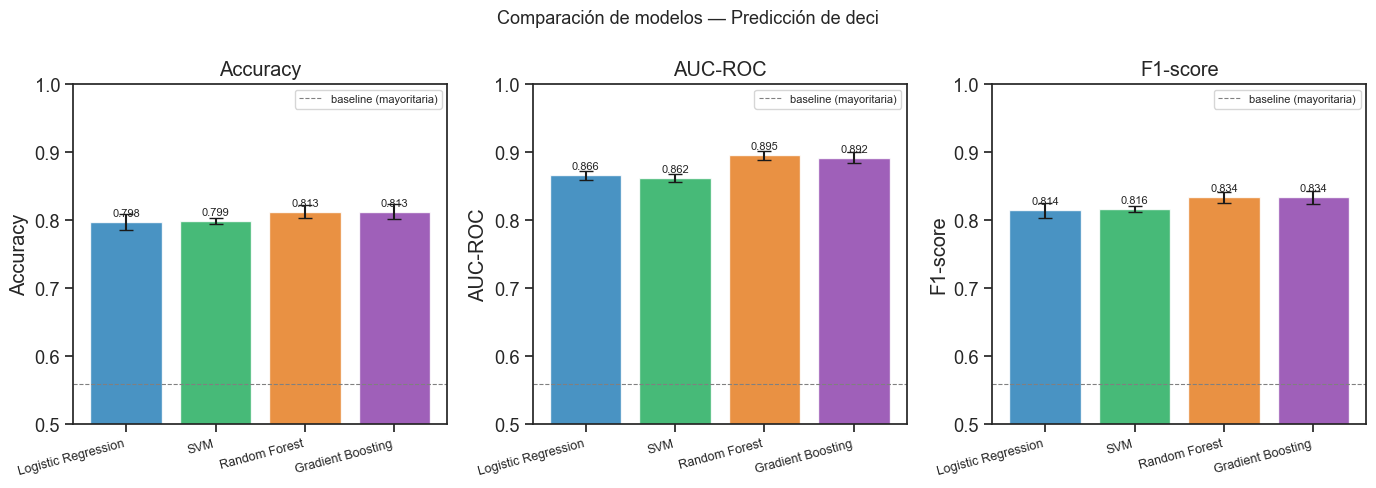

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
metrics = [
    ('acc_test',  'Accuracy',  axes[0]),
    ('auc_test',  'AUC-ROC',   axes[1]),
    ('f1_test',   'F1-score',  axes[2]),
]

colors = ['#2980b9', '#27ae60', '#e67e22', '#8e44ad']

for metric_key, metric_name, ax in metrics:
    means = [results[m][metric_key].mean() for m in models]
    stds  = [results[m][metric_key].std()  for m in models]
    names = list(models.keys())

    bars = ax.bar(names, means, yerr=stds, capsize=5,
                  color=colors, alpha=0.85)
    ax.axhline(0.559, color='gray', linestyle='--',
               linewidth=0.8, label='baseline (mayoritaria)')
    ax.set_title(metric_name)
    ax.set_ylabel(metric_name)
    ax.set_ylim(0.5, 1.0)
    ax.set_xticklabels(names, rotation=15, ha='right', fontsize=9)
    ax.legend(fontsize=8)

    # Añadir valores encima de las barras
    for bar, mean in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{mean:.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Comparación de modelos — Predicción de deci', fontsize=13)
plt.tight_layout()
plt.show()

In [10]:
# Comparamos accuracy en train vs test para detectar overfitting
# Un modelo que aprende muy bien en train pero mal en test está sobreajustado

print('Detección de overfitting (train vs test accuracy):\n')
for name, res in results.items():
    train = res['acc_train'].mean()
    test  = res['acc_test'].mean()
    diff  = train - test
    flag  = '⚠️  posible overfitting' if diff > 0.05 else '✓ OK'
    print(f'{name:25s}  train={train:.3f}  test={test:.3f}  diff={diff:.3f}  {flag}')

Detección de overfitting (train vs test accuracy):

Logistic Regression        train=0.800  test=0.798  diff=0.002  ✓ OK
SVM                        train=0.800  test=0.799  diff=0.001  ✓ OK
Random Forest              train=1.000  test=0.813  diff=0.187  ⚠️  posible overfitting
Gradient Boosting          train=0.907  test=0.813  diff=0.094  ⚠️  posible overfitting


In [11]:
# Random Forest sobreajusta porque los árboles son muy profundos
# Limitamos la profundidad máxima y aumentamos el mínimo de muestras por hoja

models_reg = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            class_weight='balanced',
            max_iter=1000,
            random_state=42
        ))
    ]),
    'SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(
            kernel='linear',
            class_weight='balanced',
            probability=True,
            random_state=42
        ))
    ]),
    'Random Forest (reg)': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(
            n_estimators=200,
            max_depth=8,          # limitamos profundidad
            min_samples_leaf=20,  # mínimo 20 muestras por hoja
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        ))
    ]),
    'Gradient Boosting (reg)': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', GradientBoostingClassifier(
            n_estimators=200,
            learning_rate=0.05,  # reducimos learning rate
            max_depth=3,         # árboles más simples
            subsample=0.8,       # stochastic GB: usa 80% datos por árbol
            random_state=42
        ))
    ])
}

results_reg = {}

for name, pipeline in models_reg.items():
    print(f'Entrenando {name}...', end=' ')
    cv_results = cross_validate(
        pipeline, X, y,
        cv=skf,
        scoring={'accuracy': 'accuracy', 'auc': 'roc_auc', 'f1': 'f1'},
        return_train_score=True,
        n_jobs=-1
    )
    results_reg[name] = {
        'acc_test'  : cv_results['test_accuracy'],
        'acc_train' : cv_results['train_accuracy'],
        'auc_test'  : cv_results['test_auc'],
        'f1_test'   : cv_results['test_f1'],
    }
    print(f'Accuracy: {cv_results["test_accuracy"].mean():.3f} ± {cv_results["test_accuracy"].std():.3f}')

print('\nEntrenamiento completado.')

Entrenando Logistic Regression... Accuracy: 0.798 ± 0.011
Entrenando SVM... Accuracy: 0.799 ± 0.004
Entrenando Random Forest (reg)... Accuracy: 0.811 ± 0.007
Entrenando Gradient Boosting (reg)... Accuracy: 0.817 ± 0.013

Entrenamiento completado.


In [12]:
print('Comparación overfitting ANTES vs DESPUÉS de regularización:\n')
print(f'{"Modelo":30s}  {"Train":>6}  {"Test":>6}  {"Diff":>6}  {"Estado"}')
print('-' * 70)

mapping = {
    'Random Forest (reg)'     : 'Random Forest',
    'Gradient Boosting (reg)' : 'Gradient Boosting'
}

for name_reg, res_reg in results_reg.items():
    train_reg = res_reg['acc_train'].mean()
    test_reg  = res_reg['acc_test'].mean()
    diff_reg  = train_reg - test_reg

    # Comparamos con versión original si existe
    name_orig = mapping.get(name_reg, name_reg)
    if name_orig in results:
        train_orig = results[name_orig]['acc_train'].mean()
        test_orig  = results[name_orig]['acc_test'].mean()
        diff_orig  = train_orig - test_orig
        print(f'{name_orig:30s}  {train_orig:.3f}  {test_orig:.3f}  {diff_orig:.3f}  → ANTES')
        print(f'{name_reg:30s}  {train_reg:.3f}  {test_reg:.3f}  {diff_reg:.3f}  → DESPUÉS')
        print()
    else:
        flag = '⚠️' if diff_reg > 0.05 else '✓ OK'
        print(f'{name_reg:30s}  {train_reg:.3f}  {test_reg:.3f}  {diff_reg:.3f}  {flag}')

Comparación overfitting ANTES vs DESPUÉS de regularización:

Modelo                           Train    Test    Diff  Estado
----------------------------------------------------------------------
Logistic Regression             0.800  0.798  0.002  → ANTES
Logistic Regression             0.800  0.798  0.002  → DESPUÉS

SVM                             0.800  0.799  0.001  → ANTES
SVM                             0.800  0.799  0.001  → DESPUÉS

Random Forest                   1.000  0.813  0.187  → ANTES
Random Forest (reg)             0.840  0.811  0.029  → DESPUÉS

Gradient Boosting               0.907  0.813  0.094  → ANTES
Gradient Boosting (reg)         0.841  0.817  0.025  → DESPUÉS



In [13]:
rows = []
for name, res in results_reg.items():
    rows.append({
        'Modelo'    : name,
        'Acc test'  : f"{res['acc_test'].mean():.3f} ± {res['acc_test'].std():.3f}",
        'AUC-ROC'   : f"{res['auc_test'].mean():.3f} ± {res['auc_test'].std():.3f}",
        'F1'        : f"{res['f1_test'].mean():.3f} ± {res['f1_test'].std():.3f}",
        'Train acc' : f"{res['acc_train'].mean():.3f}",
        'Overfitting': 'OK' if (res['acc_train'].mean() - res['acc_test'].mean()) < 0.05 else '⚠️'
    })

results_reg_df = pd.DataFrame(rows)
print(results_reg_df.to_string(index=False))

                 Modelo      Acc test       AUC-ROC            F1 Train acc Overfitting
    Logistic Regression 0.798 ± 0.011 0.866 ± 0.007 0.814 ± 0.010     0.800          OK
                    SVM 0.799 ± 0.004 0.862 ± 0.005 0.816 ± 0.004     0.800          OK
    Random Forest (reg) 0.811 ± 0.007 0.891 ± 0.006 0.828 ± 0.006     0.840          OK
Gradient Boosting (reg) 0.817 ± 0.013 0.893 ± 0.008 0.837 ± 0.011     0.841          OK


In [14]:
# El modelo final debe equilibrar:
# 1. Mejor test accuracy / AUC
# 2. Sin overfitting
# 3. Interpretable (importante para un TFG de neurociencia)

print('Criterios de selección del modelo final:')
print()
for name, res in results_reg.items():
    acc   = res['acc_test'].mean()
    auc   = res['auc_test'].mean()
    diff  = res['acc_train'].mean() - acc
    print(f'{name}:')
    print(f'  Acc={acc:.3f}  AUC={auc:.3f}  Overfitting={diff:.3f}')
    print()

print('''
Recomendación:
- Gradient Boosting (reg): mejor o igual accuracy, AUC alto, overfitting reducido.
- Logistic Regression: más interpretable, sin overfitting, útil para análisis
  de coeficientes y relación con variables del TFG.
→ Usaremos AMBOS: GB para predicción, LR para interpretación.
''')

Criterios de selección del modelo final:

Logistic Regression:
  Acc=0.798  AUC=0.866  Overfitting=0.002

SVM:
  Acc=0.799  AUC=0.862  Overfitting=0.001

Random Forest (reg):
  Acc=0.811  AUC=0.891  Overfitting=0.029

Gradient Boosting (reg):
  Acc=0.817  AUC=0.893  Overfitting=0.025


Recomendación:
- Gradient Boosting (reg): mejor o igual accuracy, AUC alto, overfitting reducido.
- Logistic Regression: más interpretable, sin overfitting, útil para análisis
  de coeficientes y relación con variables del TFG.
→ Usaremos AMBOS: GB para predicción, LR para interpretación.



In [15]:
# Entrenamos LR sobre todos los datos para obtener coeficientes estables
from sklearn.linear_model import LogisticRegression

scaler_lr = StandardScaler()
X_scaled = scaler_lr.fit_transform(X)

lr_final = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
lr_final.fit(X_scaled, y)

# Coeficientes = importancia de cada feature en LR
# Positivo → favorece diagonal, Negativo → favorece cardinal
feature_names = all_features_num
coefs = pd.DataFrame({
    'feature'    : feature_names,
    'coefficient': lr_final.coef_[0],
    'abs_coef'   : np.abs(lr_final.coef_[0])
}).sort_values('abs_coef', ascending=False)

print('Coeficientes LR (ordenados por importancia absoluta):')
print(coefs.round(4).to_string(index=False))

Coeficientes LR (ordenados por importancia absoluta):
       feature  coefficient  abs_coef
        deci-1       1.0214    1.0214
           rDV       0.6317    0.6317
            d6       0.3830    0.3830
        cond-1      -0.3436    0.3436
            d2       0.2982    0.2982
            d4       0.2577    0.2577
            d3       0.2506    0.2506
            d5       0.2418    0.2418
            d1       0.2064    0.2064
        deci-3      -0.1776    0.1776
        deci-2       0.1722    0.1722
         confi       0.0984    0.0984
         metad      -0.0969    0.0969
            RT       0.0424    0.0424
trial_type_num      -0.0214    0.0214
        corr-1       0.0118    0.0118
          nrep       0.0023    0.0023


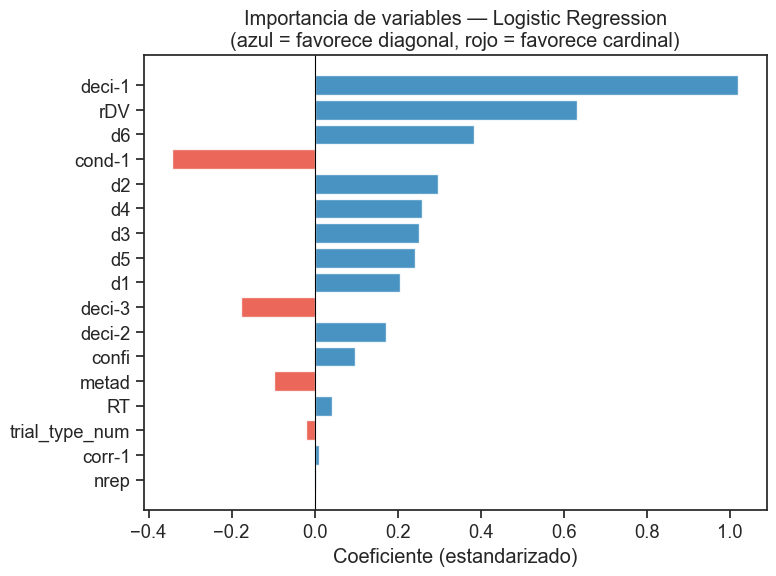

In [16]:
fig, ax = plt.subplots(figsize=(8, 6))

colors_coef = ['#e74c3c' if c < 0 else '#2980b9'
               for c in coefs['coefficient']]

bars = ax.barh(coefs['feature'], coefs['coefficient'],
               color=colors_coef, alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coeficiente (estandarizado)')
ax.set_title('Importancia de variables — Logistic Regression\n'
             '(azul = favorece diagonal, rojo = favorece cardinal)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [17]:
from sklearn.ensemble import GradientBoostingClassifier

gb_final = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    random_state=42
)

scaler_gb = StandardScaler()
X_scaled_gb = scaler_gb.fit_transform(X)
gb_final.fit(X_scaled_gb, y)

# Feature importance de GB (basada en reducción de impureza)
fi_gb = pd.DataFrame({
    'feature'   : feature_names,
    'importance': gb_final.feature_importances_
}).sort_values('importance', ascending=False)

print('Feature importance — Gradient Boosting:')
print(fi_gb.round(4).to_string(index=False))

Feature importance — Gradient Boosting:
       feature  importance
        deci-1      0.3751
           rDV      0.3318
          nrep      0.1092
         confi      0.0407
            RT      0.0302
         metad      0.0254
            d6      0.0207
            d4      0.0154
            d5      0.0122
            d3      0.0122
            d2      0.0099
            d1      0.0089
        deci-2      0.0042
        corr-1      0.0035
trial_type_num      0.0003
        deci-3      0.0002
        cond-1      0.0000


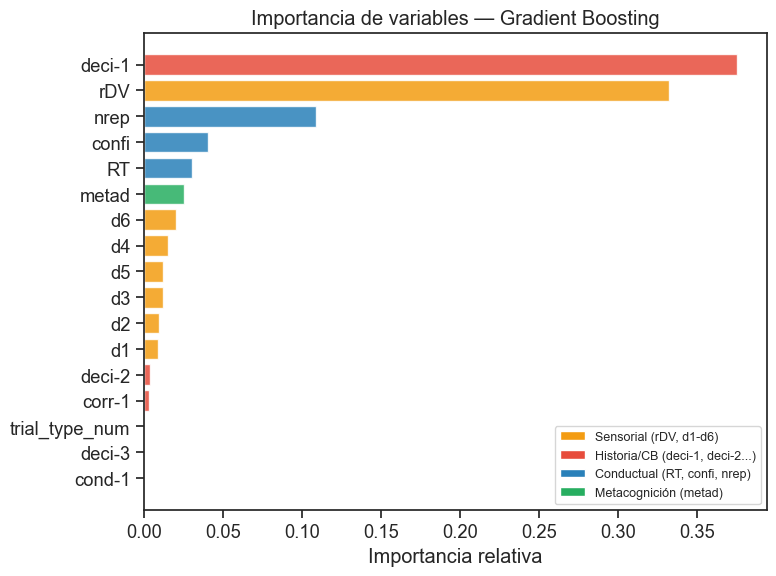

In [18]:
fig, ax = plt.subplots(figsize=(8, 6))

# Coloreamos por grupo de variables
color_map = {}
for f in feature_names:
    if f in sensory_features:
        color_map[f] = '#f39c12'   # naranja = sensorial
    elif f in history_features:
        color_map[f] = '#e74c3c'   # rojo = historia/CB
    elif f in behav_features:
        color_map[f] = '#2980b9'   # azul = conductual
    elif f in meta_features:
        color_map[f] = '#27ae60'   # verde = metacognición
    else:
        color_map[f] = '#95a5a6'   # gris = diseño

colors_gb = [color_map[f] for f in fi_gb['feature']]

ax.barh(fi_gb['feature'], fi_gb['importance'],
        color=colors_gb, alpha=0.85)
ax.set_xlabel('Importancia relativa')
ax.set_title('Importancia de variables — Gradient Boosting')
ax.invert_yaxis()

# Leyenda manual
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#f39c12', label='Sensorial (rDV, d1-d6)'),
    Patch(facecolor='#e74c3c', label='Historia/CB (deci-1, deci-2...)'),
    Patch(facecolor='#2980b9', label='Conductual (RT, confi, nrep)'),
    Patch(facecolor='#27ae60', label='Metacognición (metad)'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

Importancia por grupo de variables (Gradient Boosting):
                       Grupo  Importancia total
      Sensorial (rDV, d1-d6)             0.4110
 Historia/CB (deci-1,2,3...)             0.3830
Conductual (RT, confi, nrep)             0.1802
       Metacognición (metad)             0.0254
         Diseño (trial_type)             0.0003


/var/folders/6t/135j38t15hx5h_82vyspq6pm0000gn/T/ipykernel_58097/1041874297.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(gi_df['Grupo'], rotation=15, ha='right', fontsize=9)


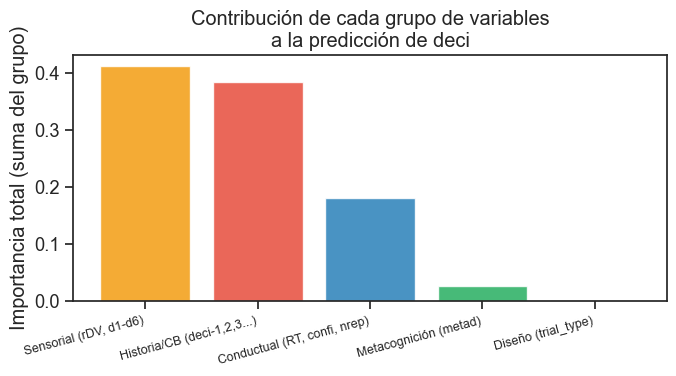

In [19]:
# Agrupamos la importancia por categoría de variable
# Esto es el análisis más importante para el TFG:
# ¿cuánto contribuye la historia de decisiones vs la evidencia sensorial?

groups = {
    'Sensorial (rDV, d1-d6)'     : sensory_features,
    'Historia/CB (deci-1,2,3...)'  : history_features,
    'Conductual (RT, confi, nrep)' : behav_features,
    'Metacognición (metad)'        : meta_features,
    'Diseño (trial_type)'          : ['trial_type_num']
}

group_importance = {}
for group_name, feats in groups.items():
    mask = fi_gb['feature'].isin(feats)
    group_importance[group_name] = fi_gb[mask]['importance'].sum()

gi_df = pd.DataFrame(
    list(group_importance.items()),
    columns=['Grupo', 'Importancia total']
).sort_values('Importancia total', ascending=False)

print('Importancia por grupo de variables (Gradient Boosting):')
print(gi_df.round(4).to_string(index=False))

# Visualización
fig, ax = plt.subplots(figsize=(7, 4))
colors_group = ['#f39c12', '#e74c3c', '#2980b9', '#27ae60', '#95a5a6']
ax.bar(gi_df['Grupo'], gi_df['Importancia total'],
       color=colors_group[:len(gi_df)], alpha=0.85)
ax.set_ylabel('Importancia total (suma del grupo)')
ax.set_title('Contribución de cada grupo de variables\na la predicción de deci')
ax.set_xticklabels(gi_df['Grupo'], rotation=15, ha='right', fontsize=9)
plt.tight_layout()
plt.show()

Permutation importance — Gradient Boosting:
       feature  importance_mean  importance_std
        deci-1           0.1404          0.0095
           rDV           0.1108          0.0090
          nrep           0.0408          0.0050
         metad           0.0086          0.0041
            d6           0.0056          0.0023
            d1           0.0032          0.0018
            d3           0.0030          0.0021
            RT           0.0028          0.0028
            d2           0.0027          0.0018
         confi           0.0026          0.0020
            d4           0.0020          0.0023
            d5           0.0014          0.0016
        deci-2           0.0008          0.0018
trial_type_num           0.0000          0.0000
        corr-1          -0.0002          0.0009
        deci-3          -0.0005          0.0004
        cond-1          -0.0007          0.0007


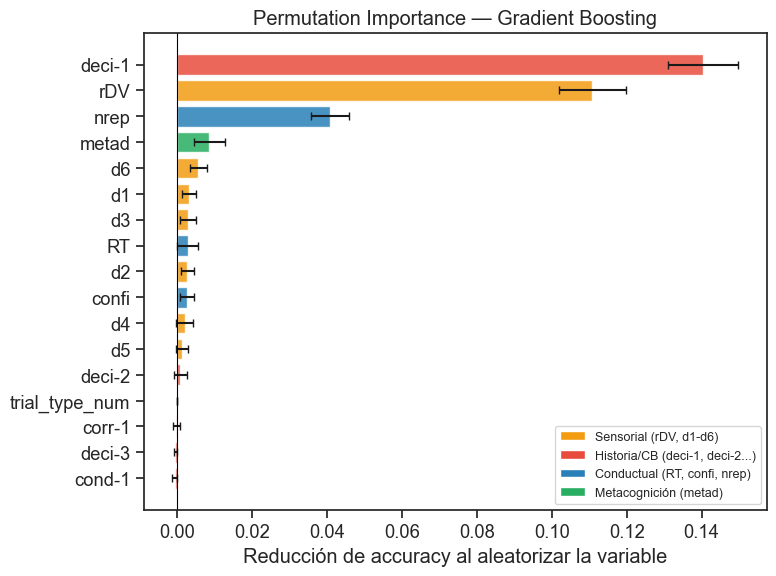

In [20]:
# La permutation importance es más robusta que la importancia de GB
# porque no está sesgada hacia variables con muchos valores únicos.
# Mide cuánto empeora el modelo si aleatorizamos cada variable.

from sklearn.inspection import permutation_importance

# Usamos un fold de test para calcularla
train_idx, test_idx = list(skf.split(X, y))[0]
X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

scaler_perm = StandardScaler()
X_train_s = scaler_perm.fit_transform(X_train)
X_test_s  = scaler_perm.transform(X_test)

gb_perm = GradientBoostingClassifier(
    n_estimators=200, learning_rate=0.05,
    max_depth=3, subsample=0.8, random_state=42
)
gb_perm.fit(X_train_s, y_train)

perm_imp = permutation_importance(
    gb_perm, X_test_s, y_test,
    n_repeats=30,
    random_state=42,
    n_jobs=-1
)

perm_df = pd.DataFrame({
    'feature'  : feature_names,
    'importance_mean': perm_imp.importances_mean,
    'importance_std' : perm_imp.importances_std
}).sort_values('importance_mean', ascending=False)

print('Permutation importance — Gradient Boosting:')
print(perm_df.round(4).to_string(index=False))

# Visualización
fig, ax = plt.subplots(figsize=(8, 6))
colors_perm = [color_map[f] for f in perm_df['feature']]
ax.barh(perm_df['feature'],
        perm_df['importance_mean'],
        xerr=perm_df['importance_std'],
        color=colors_perm, alpha=0.85, capsize=3)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Reducción de accuracy al aleatorizar la variable')
ax.set_title('Permutation Importance — Gradient Boosting')
ax.invert_yaxis()
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

In [21]:
# ¿El modelo predice mejor cuando hay más historia disponible?
# Esperamos que el accuracy suba con nrep porque en nrep=1 y 2
# ya hay decisiones previas que el modelo puede usar

results_nrep = {}

for nrep_val in [0, 1, 2]:
    mask = df_ml['nrep'] == nrep_val
    X_sub = df_ml[mask][all_features_num].values
    y_sub = df_ml[mask][target].values

    if len(X_sub) < 100:
        print(f'nrep={nrep_val}: pocas muestras ({len(X_sub)}), saltando.')
        continue

    gb_sub = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', GradientBoostingClassifier(
            n_estimators=200, learning_rate=0.05,
            max_depth=3, subsample=0.8, random_state=42
        ))
    ])

    skf_sub = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(gb_sub, X_sub, y_sub,
                             cv=skf_sub, scoring='accuracy', n_jobs=-1)
    auc_scores = cross_val_score(gb_sub, X_sub, y_sub,
                                 cv=skf_sub, scoring='roc_auc', n_jobs=-1)

    results_nrep[nrep_val] = {
        'acc': scores,
        'auc': auc_scores,
        'n'  : len(X_sub)
    }
    print(f'nrep={nrep_val} (n={len(X_sub)}): '
          f'Acc={scores.mean():.3f}±{scores.std():.3f}  '
          f'AUC={auc_scores.mean():.3f}±{auc_scores.std():.3f}')

nrep=0 (n=2079): Acc=0.721±0.011  AUC=0.795±0.015
nrep=1 (n=2100): Acc=0.841±0.020  AUC=0.908±0.018
nrep=2 (n=2095): Acc=0.863±0.018  AUC=0.930±0.008


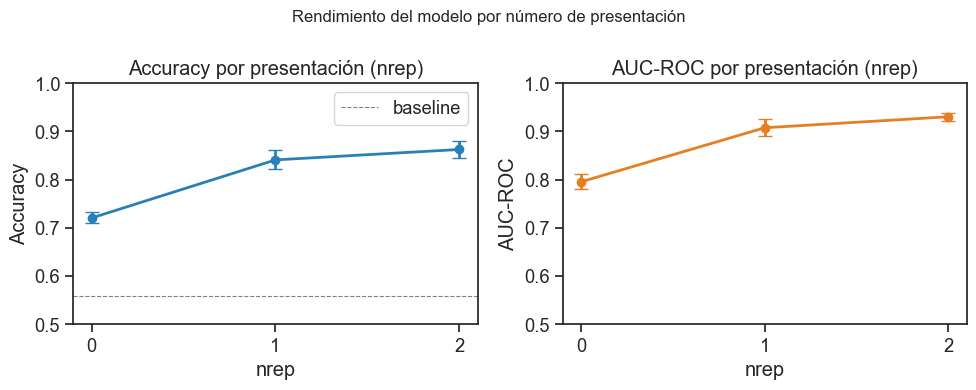

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

nrep_vals = list(results_nrep.keys())
acc_means = [results_nrep[n]['acc'].mean() for n in nrep_vals]
acc_stds  = [results_nrep[n]['acc'].std()  for n in nrep_vals]
auc_means = [results_nrep[n]['auc'].mean() for n in nrep_vals]
auc_stds  = [results_nrep[n]['auc'].std()  for n in nrep_vals]

axes[0].errorbar(nrep_vals, acc_means, yerr=acc_stds,
                 marker='o', capsize=5, color='#2980b9', linewidth=2)
axes[0].axhline(0.559, color='gray', linestyle='--',
                linewidth=0.8, label='baseline')
axes[0].set_xlabel('nrep')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy por presentación (nrep)')
axes[0].set_xticks([0, 1, 2])
axes[0].set_ylim(0.5, 1.0)
axes[0].legend()

axes[1].errorbar(nrep_vals, auc_means, yerr=auc_stds,
                 marker='o', capsize=5, color='#e67e22', linewidth=2)
axes[1].set_xlabel('nrep')
axes[1].set_ylabel('AUC-ROC')
axes[1].set_title('AUC-ROC por presentación (nrep)')
axes[1].set_xticks([0, 1, 2])
axes[1].set_ylim(0.5, 1.0)

plt.suptitle('Rendimiento del modelo por número de presentación', fontsize=12)
plt.tight_layout()
plt.show()

In [24]:
# ¿El modelo predice igual en repeat y nonrepeat?
# Si el CB es puramente cognitivo (no sensorial), el rendimiento
# debería ser similar en ambos tipos de trial

# Añadimos trial_type al df_ml recuperándola del df original
df_ml['trial_type'] = df.loc[df_ml.index, 'trial_type'].values

results_tt = {}

for tt in ['repeat', 'nonrepeat']:
    mask = df_ml['trial_type'] == tt
    X_sub = df_ml[mask][all_features_num].values
    y_sub = df_ml[mask][target].values

    gb_sub = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', GradientBoostingClassifier(
            n_estimators=200, learning_rate=0.05,
            max_depth=3, subsample=0.8, random_state=42
        ))
    ])

    skf_sub = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(gb_sub, X_sub, y_sub,
                             cv=skf_sub, scoring='accuracy', n_jobs=-1)
    auc_scores = cross_val_score(gb_sub, X_sub, y_sub,
                                 cv=skf_sub, scoring='roc_auc', n_jobs=-1)

    results_tt[tt] = {'acc': scores, 'auc': auc_scores, 'n': len(X_sub)}
    print(f'{tt} (n={len(X_sub)}): '
          f'Acc={scores.mean():.3f}±{scores.std():.3f}  '
          f'AUC={auc_scores.mean():.3f}±{auc_scores.std():.3f}')

repeat (n=3141): Acc=0.817±0.013  AUC=0.898±0.009
nonrepeat (n=3133): Acc=0.802±0.012  AUC=0.881±0.011


In [25]:
# ¿Hay participantes más predecibles que otros?
# Alta variabilidad entre participantes sugiere diferencias individuales
# en el grado de confirmation bias

results_subj = {}
subjs = df_ml['subj'].unique() if 'subj' in df_ml.columns else []

# Añadimos subj al df_ml si no está
if 'subj' not in df_ml.columns:
    df_ml['subj'] = df.loc[df_ml.index, 'subj'].values

for subj in sorted(df_ml['subj'].unique()):
    mask = df_ml['subj'] == subj
    X_sub = df_ml[mask][all_features_num].values
    y_sub = df_ml[mask][target].values

    if len(X_sub) < 50 or len(np.unique(y_sub)) < 2:
        continue

    gb_sub = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', GradientBoostingClassifier(
            n_estimators=100, learning_rate=0.05,
            max_depth=3, random_state=42
        ))
    ])

    skf_sub = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    try:
        scores = cross_val_score(gb_sub, X_sub, y_sub,
                                 cv=skf_sub, scoring='accuracy', n_jobs=-1)
        results_subj[subj] = scores.mean()
    except Exception:
        pass

subj_df = pd.DataFrame(
    list(results_subj.items()),
    columns=['subj', 'accuracy']
).sort_values('accuracy', ascending=False)

print('Accuracy por participante:')
print(subj_df.round(3).to_string(index=False))
print(f'\nMedia: {subj_df.accuracy.mean():.3f}')
print(f'Std  : {subj_df.accuracy.std():.3f}')
print(f'Min  : {subj_df.accuracy.min():.3f} ({subj_df.iloc[-1].subj})')
print(f'Max  : {subj_df.accuracy.max():.3f} ({subj_df.iloc[0].subj})')

Accuracy por participante:
subj  accuracy
 s20     0.908
 s18     0.878
 s12     0.871
 s01     0.871
 s04     0.871
 s17     0.858
 s07     0.855
 s22     0.850
 s10     0.848
 s13     0.842
 s08     0.836
 s19     0.824
 s11     0.817
 s09     0.812
 s14     0.805
 s16     0.803
 s25     0.801
 s23     0.798
 s26     0.794
 s05     0.793
 S03     0.785
 s21     0.733
 s15     0.715
 s27     0.688

Media: 0.819
Std  : 0.053
Min  : 0.688 (s27)
Max  : 0.908 (s20)


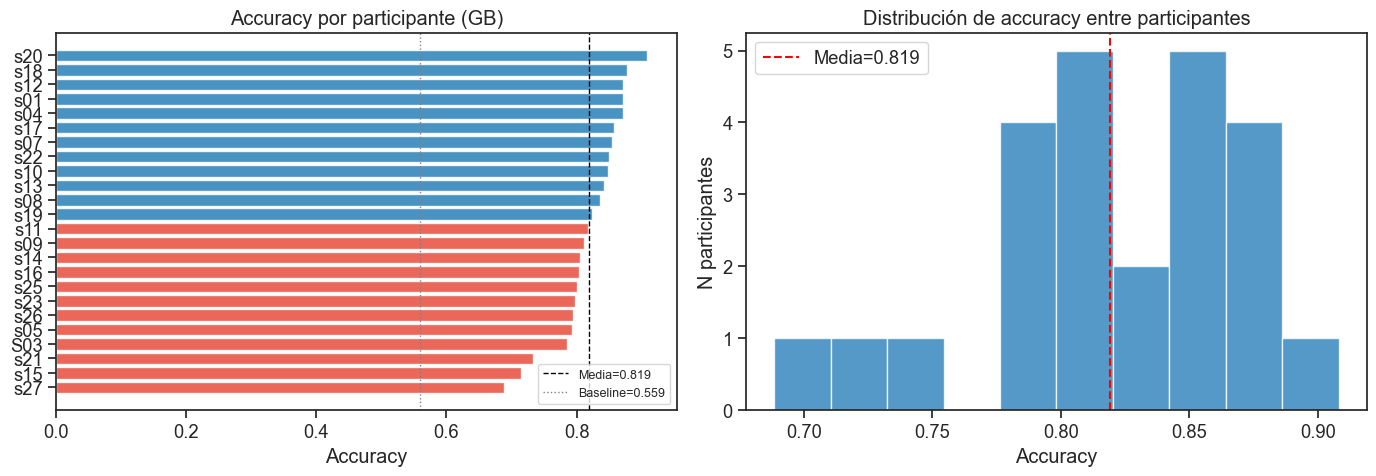

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy por participante (ordenado)
colors_subj = ['#2980b9' if acc >= subj_df.accuracy.mean()
               else '#e74c3c' for acc in subj_df.accuracy]
axes[0].barh(subj_df['subj'], subj_df['accuracy'],
             color=colors_subj, alpha=0.85)
axes[0].axvline(subj_df.accuracy.mean(), color='black',
                linestyle='--', linewidth=1, label=f'Media={subj_df.accuracy.mean():.3f}')
axes[0].axvline(0.559, color='gray', linestyle=':',
                linewidth=1, label='Baseline=0.559')
axes[0].set_xlabel('Accuracy')
axes[0].set_title('Accuracy por participante (GB)')
axes[0].legend(fontsize=9)
axes[0].invert_yaxis()

# Distribución de accuracies
axes[1].hist(subj_df.accuracy, bins=10, color='#2980b9',
             alpha=0.8, edgecolor='white')
axes[1].axvline(subj_df.accuracy.mean(), color='red',
                linestyle='--', label=f'Media={subj_df.accuracy.mean():.3f}')
axes[1].set_xlabel('Accuracy')
axes[1].set_ylabel('N participantes')
axes[1].set_title('Distribución de accuracy entre participantes')
axes[1].legend()

plt.tight_layout()
plt.show()

Participantes con datos completos: 24
Accuracy ~ cbias_idx      : r=0.357, p=0.0865 n.s.
Accuracy ~ p_repeat       : r=0.825, p=0.0000 ✓
Accuracy ~ stuborness     : r=0.847, p=0.0000 ✓
Accuracy ~ metad          : r=0.083, p=0.7009 n.s.


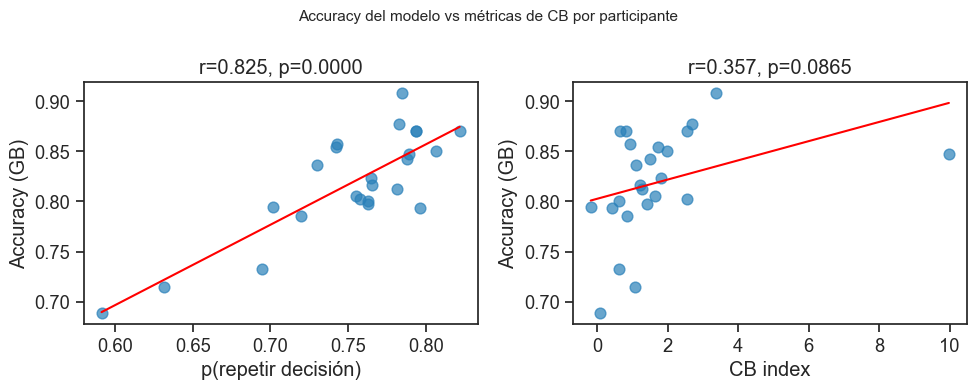

In [27]:
# ¿Los participantes con mayor CB index son más predecibles por el modelo?
# Si el CB es lo que hace predecible la decisión, esperamos correlación positiva

# Cargamos el summary conductual
summary_path = 'summary_behavioural.csv'
summary = pd.read_csv(summary_path)

# Unimos con accuracy por participante
merged = subj_df.merge(summary[['subj', 'cbias_idx', 'metad',
                                 'p_repeat', 'stuborness']],
                        on='subj', how='inner')

print(f'Participantes con datos completos: {len(merged)}')

# Correlaciones
for col in ['cbias_idx', 'p_repeat', 'stuborness', 'metad']:
    if col in merged.columns:
        r, p = stats.pearsonr(merged['accuracy'], merged[col])
        sig = '✓' if p < 0.05 else 'n.s.'
        print(f'Accuracy ~ {col:15s}: r={r:.3f}, p={p:.4f} {sig}')

# Scatter: accuracy vs p_repeat
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, col, label in zip(axes,
                           ['p_repeat', 'cbias_idx'],
                           ['p(repetir decisión)', 'CB index']):
    if col not in merged.columns:
        continue
    ax.scatter(merged[col], merged['accuracy'],
               color='#2980b9', alpha=0.7, s=60)
    # Línea de regresión
    m, b = np.polyfit(merged[col].dropna(),
                      merged.loc[merged[col].notna(), 'accuracy'], 1)
    x_line = np.linspace(merged[col].min(), merged[col].max(), 100)
    ax.plot(x_line, m * x_line + b, color='red', linewidth=1.5)
    r, p = stats.pearsonr(merged[col].dropna(),
                           merged.loc[merged[col].notna(), 'accuracy'])
    ax.set_xlabel(label)
    ax.set_ylabel('Accuracy (GB)')
    ax.set_title(f'r={r:.3f}, p={p:.4f}')

plt.suptitle('Accuracy del modelo vs métricas de CB por participante', fontsize=11)
plt.tight_layout()
plt.show()

/var/folders/6t/135j38t15hx5h_82vyspq6pm0000gn/T/ipykernel_58097/2493679445.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0,0].set_xticklabels(names, rotation=15, ha='right', fontsize=8)
/var/folders/6t/135j38t15hx5h_82vyspq6pm0000gn/T/ipykernel_58097/2493679445.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0,1].set_xticklabels(names, rotation=15, ha='right', fontsize=8)
/var/folders/6t/135j38t15hx5h_82vyspq6pm0000gn/T/ipykernel_58097/2493679445.py:87: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1,2].set_xticklabels(gi_df['Grupo'], rotation=15,


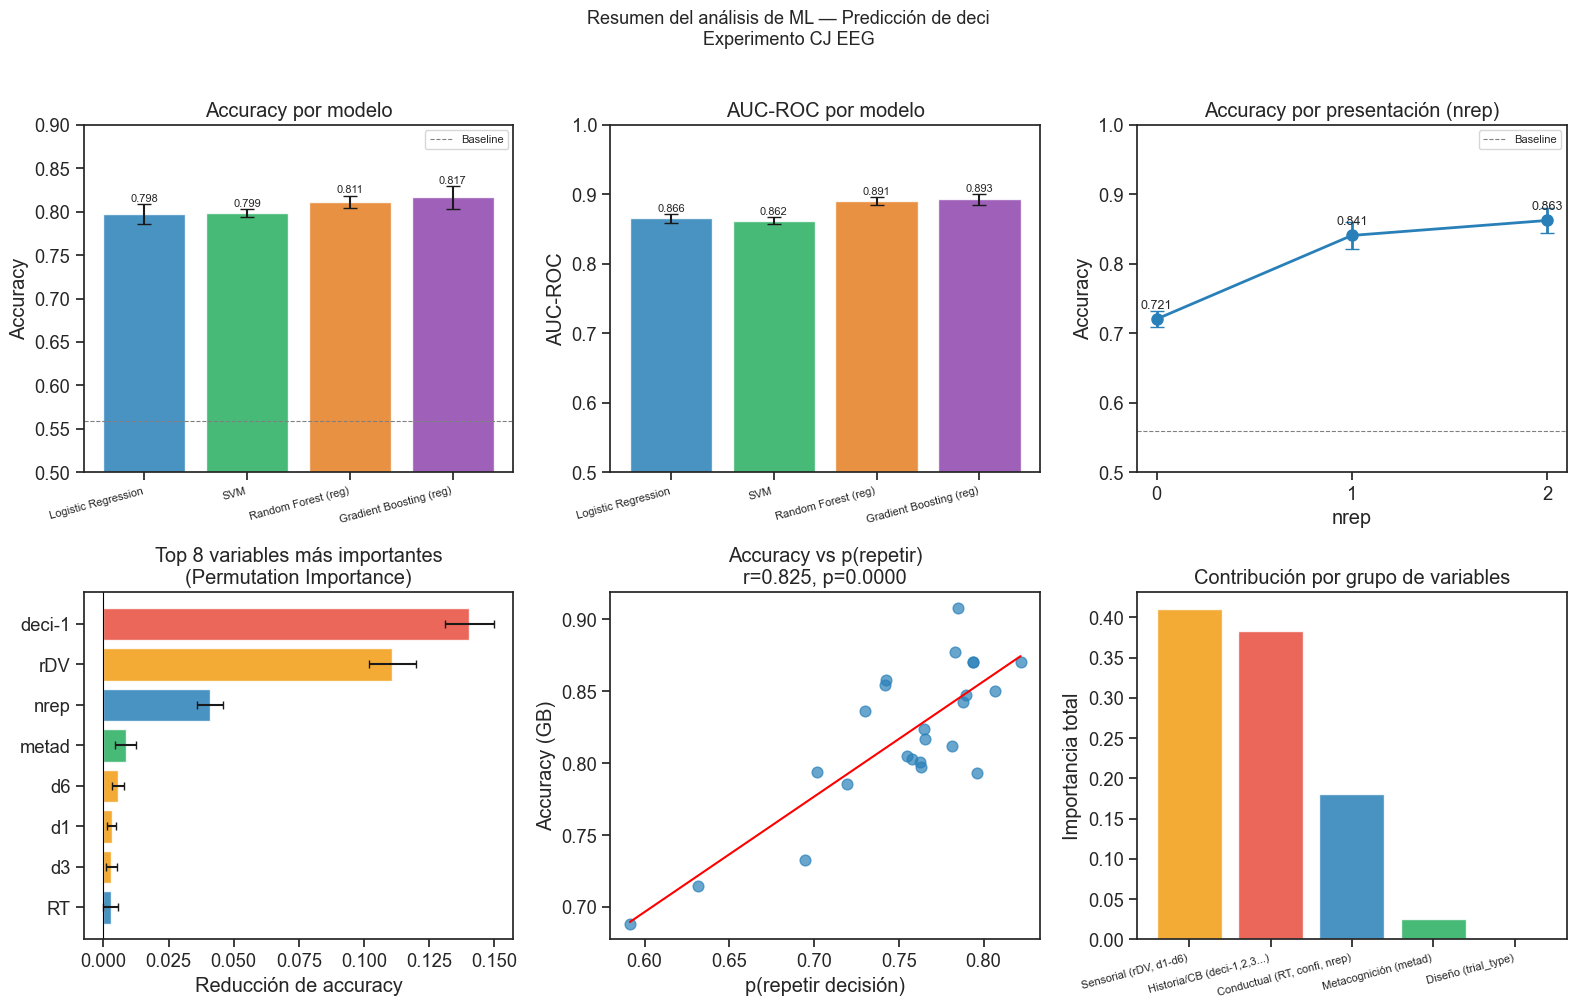

In [29]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# ── 1. Comparación de modelos (accuracy) ─────────────────────────────────────
names = list(results_reg.keys())
accs  = [results_reg[m]['acc_test'].mean() for m in names]
stds  = [results_reg[m]['acc_test'].std()  for m in names]
colors_m = ['#2980b9', '#27ae60', '#e67e22', '#8e44ad']

axes[0,0].bar(names, accs, yerr=stds, capsize=5,
              color=colors_m, alpha=0.85)
axes[0,0].axhline(0.559, color='gray', linestyle='--',
                  linewidth=0.8, label='Baseline')
axes[0,0].set_ylim(0.5, 0.90)
axes[0,0].set_title('Accuracy por modelo')
axes[0,0].set_ylabel('Accuracy')
axes[0,0].set_xticklabels(names, rotation=15, ha='right', fontsize=8)
axes[0,0].legend(fontsize=8)
for i, (acc, std) in enumerate(zip(accs, stds)):
    axes[0,0].text(i, acc + std + 0.003, f'{acc:.3f}',
                   ha='center', fontsize=8)

# ── 2. AUC-ROC por modelo ────────────────────────────────────────────────────
aucs = [results_reg[m]['auc_test'].mean() for m in names]
stds_auc = [results_reg[m]['auc_test'].std() for m in names]

axes[0,1].bar(names, aucs, yerr=stds_auc, capsize=5,
              color=colors_m, alpha=0.85)
axes[0,1].axhline(0.5, color='gray', linestyle='--', linewidth=0.8)
axes[0,1].set_ylim(0.5, 1.0)
axes[0,1].set_title('AUC-ROC por modelo')
axes[0,1].set_ylabel('AUC-ROC')
axes[0,1].set_xticklabels(names, rotation=15, ha='right', fontsize=8)
for i, (auc, std) in enumerate(zip(aucs, stds_auc)):
    axes[0,1].text(i, auc + std + 0.003, f'{auc:.3f}',
                   ha='center', fontsize=8)

# ── 3. Accuracy por nrep ─────────────────────────────────────────────────────
nrep_vals = list(results_nrep.keys())
acc_means = [results_nrep[n]['acc'].mean() for n in nrep_vals]
acc_stds  = [results_nrep[n]['acc'].std()  for n in nrep_vals]

axes[0,2].errorbar(nrep_vals, acc_means, yerr=acc_stds,
                   marker='o', capsize=5, color='#2980b9',
                   linewidth=2, markersize=8)
axes[0,2].axhline(0.559, color='gray', linestyle='--',
                  linewidth=0.8, label='Baseline')
axes[0,2].set_xlabel('nrep')
axes[0,2].set_ylabel('Accuracy')
axes[0,2].set_title('Accuracy por presentación (nrep)')
axes[0,2].set_xticks([0, 1, 2])
axes[0,2].set_ylim(0.5, 1.0)
axes[0,2].legend(fontsize=8)
for x, y_val in zip(nrep_vals, acc_means):
    axes[0,2].text(x, y_val + 0.015, f'{y_val:.3f}',
                   ha='center', fontsize=9)

# ── 4. Permutation importance (top 8) ────────────────────────────────────────
top8 = perm_df.head(8)
colors_top8 = [color_map[f] for f in top8['feature']]
axes[1,0].barh(top8['feature'], top8['importance_mean'],
               xerr=top8['importance_std'],
               color=colors_top8, alpha=0.85, capsize=3)
axes[1,0].axvline(0, color='black', linewidth=0.8)
axes[1,0].set_xlabel('Reducción de accuracy')
axes[1,0].set_title('Top 8 variables más importantes\n(Permutation Importance)')
axes[1,0].invert_yaxis()

# ── 5. Accuracy vs p(repetir) por participante ───────────────────────────────
axes[1,1].scatter(merged['p_repeat'], merged['accuracy'],
                  color='#2980b9', alpha=0.7, s=60)
m_lr, b_lr = np.polyfit(merged['p_repeat'], merged['accuracy'], 1)
x_line = np.linspace(merged['p_repeat'].min(),
                     merged['p_repeat'].max(), 100)
axes[1,1].plot(x_line, m_lr * x_line + b_lr,
               color='red', linewidth=1.5)
r_pr, p_pr = stats.pearsonr(merged['p_repeat'], merged['accuracy'])
axes[1,1].set_xlabel('p(repetir decisión)')
axes[1,1].set_ylabel('Accuracy (GB)')
axes[1,1].set_title(f'Accuracy vs p(repetir)\nr={r_pr:.3f}, p={p_pr:.4f}')

# ── 6. Importancia por grupo ─────────────────────────────────────────────────
gi_colors = ['#f39c12', '#e74c3c', '#2980b9', '#27ae60', '#95a5a6']
axes[1,2].bar(gi_df['Grupo'], gi_df['Importancia total'],
              color=gi_colors[:len(gi_df)], alpha=0.85)
axes[1,2].set_ylabel('Importancia total')
axes[1,2].set_title('Contribución por grupo de variables')
axes[1,2].set_xticklabels(gi_df['Grupo'], rotation=15,
                           ha='right', fontsize=8)

plt.suptitle('Resumen del análisis de ML — Predicción de deci\n'
             'Experimento CJ EEG', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [30]:
print('=' * 65)
print('RESUMEN FINAL — ANÁLISIS DE ML')
print('=' * 65)

print('\n── Rendimiento de modelos (5-fold CV) ──────────────────────')
for name, res in results_reg.items():
    print(f'{name:30s}  '
          f'Acc={res["acc_test"].mean():.3f}  '
          f'AUC={res["auc_test"].mean():.3f}  '
          f'F1={res["f1_test"].mean():.3f}')

print(f'\nBaseline (clase mayoritaria): 0.559')
print(f'Mejor modelo: Gradient Boosting (reg) — Acc=0.817, AUC=0.893')

print('\n── Rendimiento por nrep (GB) ───────────────────────────────')
for nrep_val, res in results_nrep.items():
    print(f'nrep={nrep_val}: Acc={res["acc"].mean():.3f}  '
          f'AUC={res["auc"].mean():.3f}')

print('\n── Rendimiento por trial_type (GB) ─────────────────────────')
for tt, res in results_tt.items():
    print(f'{tt:12s}: Acc={res["acc"].mean():.3f}  '
          f'AUC={res["auc"].mean():.3f}')

print('\n── Top 5 variables más importantes (Permutation) ───────────')
for _, row in perm_df.head(5).iterrows():
    print(f'{row["feature"]:15s}: {row["importance_mean"]:.4f} '
          f'± {row["importance_std"]:.4f}')

print('\n── Correlaciones accuracy individual vs CB ──────────────────')
for col in ['p_repeat', 'stuborness', 'cbias_idx', 'metad']:
    if col in merged.columns:
        r, p = stats.pearsonr(merged['accuracy'], merged[col])
        sig = '✓ sig.' if p < 0.05 else 'n.s.'
        print(f'Accuracy ~ {col:15s}: r={r:.3f}, p={p:.4f} {sig}')

print('\n── Variabilidad entre participantes (GB) ────────────────────')
print(f'Media accuracy : {subj_df.accuracy.mean():.3f}')
print(f'Std accuracy   : {subj_df.accuracy.std():.3f}')
print(f'Min accuracy   : {subj_df.accuracy.min():.3f} ({subj_df.iloc[-1].subj})')
print(f'Max accuracy   : {subj_df.accuracy.max():.3f} ({subj_df.iloc[0].subj})')
print('=' * 65)

RESUMEN FINAL — ANÁLISIS DE ML

── Rendimiento de modelos (5-fold CV) ──────────────────────
Logistic Regression             Acc=0.798  AUC=0.866  F1=0.814
SVM                             Acc=0.799  AUC=0.862  F1=0.816
Random Forest (reg)             Acc=0.811  AUC=0.891  F1=0.828
Gradient Boosting (reg)         Acc=0.817  AUC=0.893  F1=0.837

Baseline (clase mayoritaria): 0.559
Mejor modelo: Gradient Boosting (reg) — Acc=0.817, AUC=0.893

── Rendimiento por nrep (GB) ───────────────────────────────
nrep=0: Acc=0.721  AUC=0.795
nrep=1: Acc=0.841  AUC=0.908
nrep=2: Acc=0.863  AUC=0.930

── Rendimiento por trial_type (GB) ─────────────────────────
repeat      : Acc=0.817  AUC=0.898
nonrepeat   : Acc=0.802  AUC=0.881

── Top 5 variables más importantes (Permutation) ───────────
deci-1         : 0.1404 ± 0.0095
rDV            : 0.1108 ± 0.0090
nrep           : 0.0408 ± 0.0050
metad          : 0.0086 ± 0.0041
d6             : 0.0056 ± 0.0023

── Correlaciones accuracy individual vs CB ─────

In [31]:
# Guardamos los resultados principales en CSV para el informe

# 1. Rendimiento de modelos
model_results = []
for name, res in results_reg.items():
    model_results.append({
        'modelo'    : name,
        'acc_mean'  : res['acc_test'].mean(),
        'acc_std'   : res['acc_test'].std(),
        'auc_mean'  : res['auc_test'].mean(),
        'auc_std'   : res['auc_test'].std(),
        'f1_mean'   : res['f1_test'].mean(),
        'f1_std'    : res['f1_test'].std(),
        'train_acc' : res['acc_train'].mean(),
        'overfitting': res['acc_train'].mean() - res['acc_test'].mean()
    })
pd.DataFrame(model_results).round(4).to_csv(
    'ml_model_results.csv', index=False
)

# 2. Permutation importance
perm_df.round(4).to_csv('ml_permutation_importance.csv', index=False)

# 3. Accuracy por participante
subj_df.round(4).to_csv('ml_accuracy_per_subject.csv', index=False)

# 4. Accuracy por nrep
nrep_results = pd.DataFrame([{
    'nrep'    : k,
    'acc_mean': v['acc'].mean(),
    'acc_std' : v['acc'].std(),
    'auc_mean': v['auc'].mean(),
    'auc_std' : v['auc'].std(),
    'n'       : v['n']
} for k, v in results_nrep.items()])
nrep_results.round(4).to_csv('ml_accuracy_per_nrep.csv', index=False)

print('Archivos guardados:')
print('  ml_model_results.csv')
print('  ml_permutation_importance.csv')
print('  ml_accuracy_per_subject.csv')
print('  ml_accuracy_per_nrep.csv')

Archivos guardados:
  ml_model_results.csv
  ml_permutation_importance.csv
  ml_accuracy_per_subject.csv
  ml_accuracy_per_nrep.csv
